## What IS Maximum Likelihood Estimation?  
Most people are familiar with the concept of the average value - you sum up all the individual measurements in a sample and divide it by the number of values in that sample. This method is a form of point estimation - you use all the sample data to calculate a single numerical value that estimates the true population mean. Maximum Likelihood Estimation (MLE) is also an estimation method used to select a value for an unknown parameter, like the mean. It maximises the fit between your suggested model and the actual, observed data. I'm going to walk through the process below, unpacking each step. 

When you apply MLE, you need two things:  
1. Some data
2. An idea of the distribution you're working with

Let's look at how this works given two different distributions, namely binomial and normal.

### Binomial distribution (coin flips)
In the first instance, let's apply MLE to figure out if a coin we're flipping is biased or not (i.e. we want to estimate the parameter p). If a coin is unbiased, the probability to flip heads = the probability to flip tails = 0.5. So we will definitely test that value as a potential probability, and then go higher. Let's say we flip a coin 10 times and get the following values.

In [252]:
import matplotlib.pyplot as plt
import numpy as np
x = np.array([1, 1, 1, 0, 1, 0, 1, 1, 0, 1])

In [254]:
heads = x.sum()
tails = len(x)-heads
print(heads, tails)

7 3


For a binomial distribution the likelihood function is:
$$
L(p \mid n, y) = \binom{n}{y} p^y (1-p)^{n-y}
$$  

In other words, the likelihood of probability p, given the data (n and y) is the total number of ways the y outcome can be obtained in n attempts, multiplied by (the probability of y to the power of the number of times y is observed) multiplied by (the probability of the other outcome to the power of the number of times the opposite outcome is observed).

So in the coin example, the likelihood of probability p (given the observed values in the array x) is equal to the number of ways that we can get heads (y) in n number of flips, multiplied by the probability for heads (to the power of the number of heads observed) multiplied by the probability for tails (to the power of the number of tails observed).

We can simplify this expression by omiting the binomial coefficient ("n choose y") because it does not contain the parameter p and is a constant. So let's calculate the likelihood of different values of p (probability of heads) given our data above.


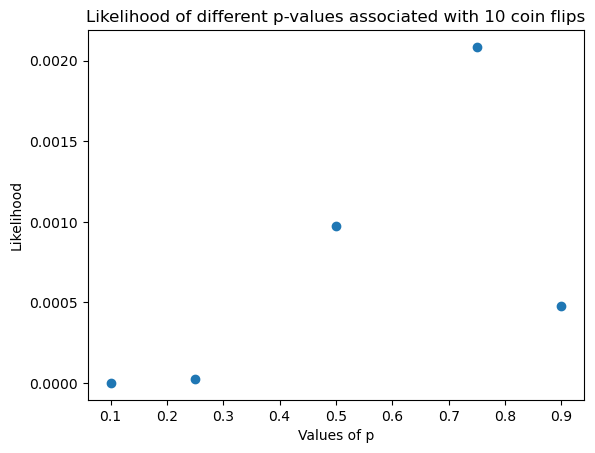

In [257]:
def likelihood(p, n_heads, n_tails):
    return p**n_heads*(1-p)**n_tails

values_of_p = np.array([0.1, 0.25, 0.5, 0.75, 0.9])

likelihood_tracker = []

for i in range(len(values_of_p)):
    curr_likelihood = likelihood(values_of_p[i], heads, tails)
    likelihood_tracker.append(curr_likelihood)

# plot outcome of test
plt.scatter(values_of_p, likelihood_tracker)
plt.title("Likelihood of different p-values associated with 10 coin flips")
plt.xlabel("Values of p")
plt.ylabel("Likelihood")
plt.show()

We can see that the maximal value for the likelihood equation was returned when we plugged in p = 0.75, so we already have an inclination that our coin is biased, based on the maximum likelihood calculated.

In order to make the calculations easier, we can calculate the logarithm of the likelihood. When we do this, we can apply the rule:  
log(a * b) = log(a) + log(b). So our calculation of the likelihood turns into the log-likelihood:

log(L(p | n,y)) = log((p^y) (1-p)^(n-y)) = y log(p) + (n-y) log(1-p)

where y = number of heads and (n-y) = number of tails.

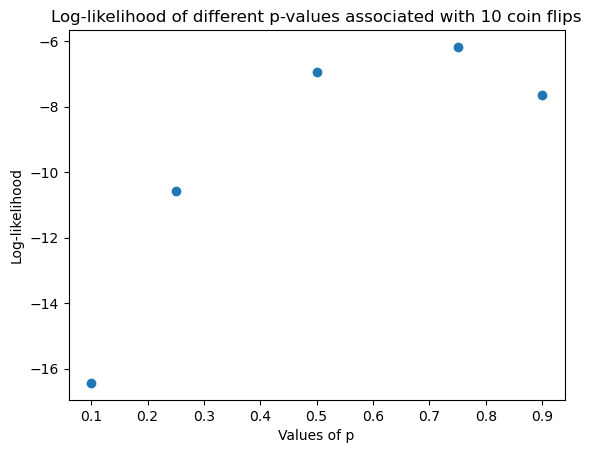

In [261]:
def log_likelihood(p, n_heads, n_tails):
    return n_heads*np.log(p) + n_tails*np.log(1-p)

log_likelihood_tracker = []

for i in range(len(values_of_p)):
    curr_likelihood = log_likelihood(values_of_p[i], heads, tails)
    log_likelihood_tracker.append(curr_likelihood)

# plot outcome of test
plt.scatter(values_of_p, log_likelihood_tracker)
plt.title("Log-likelihood of different p-values associated with 10 coin flips")
plt.xlabel("Values of p")
plt.ylabel("Log-likelihood")
plt.show()

How can we test a range of p-values quickly without manually choosing each value? Let's import a tool from the SciPy module to help. Because this tool aims to **minimise** a value, we first have to invert the sign in our log-likelihood value to get the **maximum** likelihood.

In [264]:
from scipy.optimize import minimize_scalar

def negative_log_likelihood(p):
    return -log_likelihood(p, heads, tails)
    
result = minimize_scalar(
    negative_log_likelihood,
    bounds=(0.001, 0.999),
    method="bounded"
)

# maximal p-value
print(result.x)


0.7000003494291321


/var/folders/24/py7xd68s53d9d2s_0x1brn5w0000gn/T/ipykernel_8784/1361840058.py:2: RuntimeWarning: divide by zero encountered in log
  return n_heads*np.log(p) + n_tails*np.log(1-p)


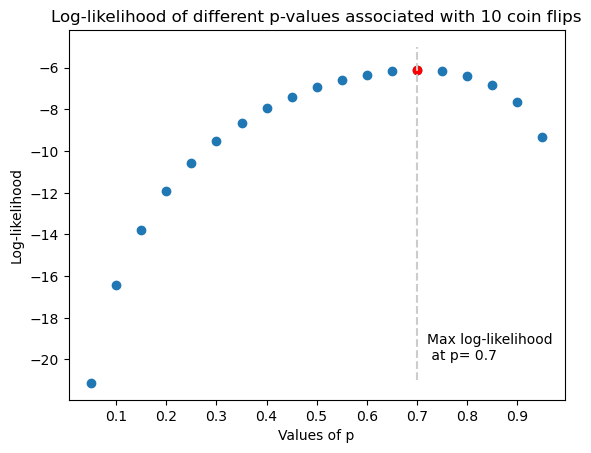

In [266]:
# graphing what this might look like
range_of_p = np.arange(0, 1, 0.05)

log_likelihood_tracker = []

for i in range(len(range_of_p)):
    curr_likelihood = log_likelihood(range_of_p[i], heads, tails)
    log_likelihood_tracker.append(curr_likelihood)

# plot outcome of test
plt.scatter(range_of_p, log_likelihood_tracker)
plt.scatter(x=result.x, y=-result.fun, color='r')
plt.xticks(ticks=np.arange(0, 1, 0.1))
plt.title("Log-likelihood of different p-values associated with 10 coin flips")
plt.xlabel("Values of p")
plt.ylabel("Log-likelihood")
plt.vlines(0.7, -21, -5, colors='0.8', linestyles='dashed')
plt.annotate("Max log-likelihood\n at p= %1.1f" % result.x, xy=(0.72, -20))
plt.show()

### Normal distribution    
OK, but what do we do when we have a normal distribution? Let's expand our analysis to a scenario beyond two discrete outcomes. In this case we could be working with a continous variable (like height, weight, or yield) and the parameter we are trying to estimate could be something like the mean.

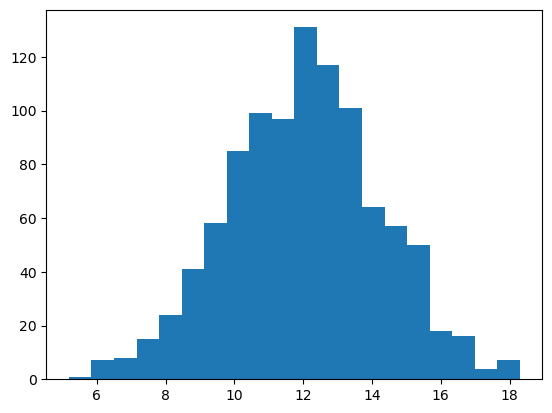

In [269]:
# make results reproducible
import random
random.seed(123)

# generate some random numbers that come from a normal distribution, with mean = 12 and standard deviation = 2.3
x = np.random.normal(loc=12, scale=2.3, size=1000)

plt.hist(x, bins=20)
plt.show()

Using the same approach as above I will define a function that calculates the negative log-likelihood (so I can use Scipy's `optimize` functions).

We are assuming that our data is independent and identically distributed (*i.i.d*), and conforms to a normal distribution with mean of $\mu$ , and variance of $\sigma^{2}$ (recall that standard deviation = square root of variance). The equation that describes the probability density of a normal distribution is:  

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$  

Where X is my dataset, $\sigma^{2}$ will be assumed (we can set it to 1 to make things simple), and $\mu$ will be determined. The log-likelihood of $\mu$ in this scenario is:

$$\log L(\mu)= \sum_{i=1}^{N} \log \left[\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)\right]$$  

We use the fact that log(ab) = log(a) + log(b) and also log(exp^x) = x in the function.

In [272]:
# use log-likelihood equation above to define function
def log_likelihood(mu, data, sigma2):
    return np.sum(
        -0.5 * np.log(2 * np.pi * sigma2**2) - (data-mu)**2 / (2* sigma2**2)
    )
    
def negative_log_likelihood(mu, data, sigma2):
    return -log_likelihood(mu, data, sigma2)

# minimize scalar will optimize for the FIRST argument in the function; you must provide the other two IN ORDER
# I've chosen the bounds (10,14) because I can see from the histogram above that the mean should be somewhere between these values
result = minimize_scalar(
    negative_log_likelihood,
    args=(x,1),
    bounds=(10,14),
    method="bounded"
)

# maximal p-value
print(result.x)

12.023737763757037


Let's graph what this might look like as before.

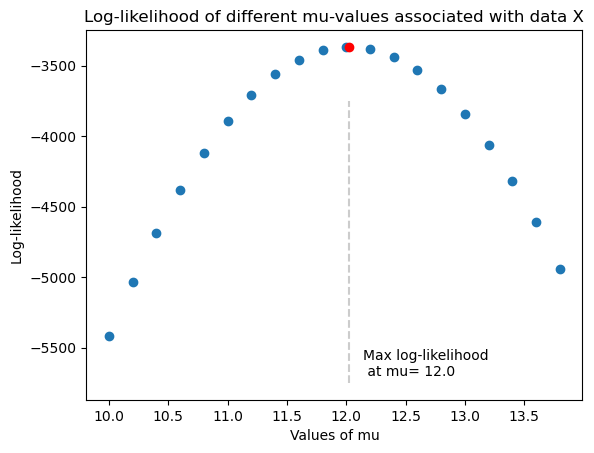

In [275]:
range_of_mu = np.arange(10, 14, 0.2)

log_likelihood_tracker = []

for i in range(len(range_of_mu)):
    curr_likelihood = log_likelihood(range_of_mu[i], x, 1)
    log_likelihood_tracker.append(curr_likelihood)

# plot outcome of test
plt.scatter(range_of_mu, log_likelihood_tracker)
plt.scatter(x=result.x, y=-result.fun, color='r')
plt.xticks(ticks=np.arange(9, 15, 0.5))
plt.title("Log-likelihood of different mu-values associated with data X")
plt.xlabel("Values of mu")
plt.ylabel("Log-likelihood")
plt.vlines(result.x, -5750, -3750, colors='0.8', linestyles='dashed')
plt.annotate("Max log-likelihood\n at mu= %1.1f" % result.x, xy=(result.x*1.01, -5700))
plt.show()

In Python there is a neat little function in SciPy that will return the probability density (height of the curve) at a given input value x `logpdf`. We can use this instead of the whole equation above to simplify our function. Let's test it out to see if we get the same result.

In [278]:
from scipy.stats import norm

def negative_log_likelihood(mu, data, sigma2):
    log_density = norm.logpdf(data, loc=mu, scale=sigma2)
    return(-sum(log_density))

result = minimize_scalar(
    negative_log_likelihood,
    args=(x,1),
    bounds=(10,14),
    method="bounded"
)

# maximal p-value
print(result.x)           

12.023737763757032


OK, this all works if we're estimating a single parameter, but what if we need to estimate both the mean and the standard deviation? Above we have assumed an SD of 1, but this is not the true value, since we originally set that to 2.3. Now we will have to compute the probability density for both mean and sd, for each value in our dataset (X). Let's adjust our function.

In [281]:
def negative_log_likelihood_two_params(theta, data):
    mu = theta[0]
    sigma2 = theta[1]
    log_density = norm.logpdf(data, loc=mu, scale=np.sqrt(sigma2))
    return(-np.sum(log_density))

In this new definition, we pack both parameters into a single variable called `theta`, which we unpack inside the function. Now we can optimise for both values at once.

In [284]:
# import minimize since we're not working with single, scalar value here
from scipy.optimize import minimize

theta_init = np.array([1,1])

result = minimize(
    negative_log_likelihood_two_params, 
    theta_init,
    args=(x,),
    method="L-BFGS-B",
    bounds=[
        (None, None), # set bounds for mu
        (0.001, None) # set bounds for sigma2
    ]
)

# maximal values for mu and sigma2
print(result.x)       

[12.02373507  4.89856411]


To visualise the different combinations of mu and sigma2 generated by running the negative_log_likelihood_two_params function inside `minimize`, we will have to draw a two-dimensional contour plot. To do this we will first have to generate a grid of values for `mu` and `sigma2`, and then apply the negative_log_likelihood_two_params function to the grid to generate a value for each position in the grid.

In [287]:
# values for mu
mu_values = np.linspace(-1, 20, 101)

# values for sigma2
sigma2_values = np.linspace(1, 20, 101)

# repate each value in the 1D array 101 times
mu_xx = np.repeat(mu_values, 101)
sigma2_yy = np.tile(sigma2_values, 101)

# create 2-column grid with mu and sd2 
mu_sigma_grid = np.column_stack((mu_xx, sigma2_yy))

In [289]:
# apply the two-parameter log-likelihood function row-wise (i.e. in pairs of mu and sigma2)
neg_log_L_2params = np.array([
    negative_log_likelihood_two_params(theta,x)
    for theta in mu_sigma_grid
])

neg_log_L_2params.shape

(10201,)

Convert vector ouput into a 101 x 101 matrix and plot!

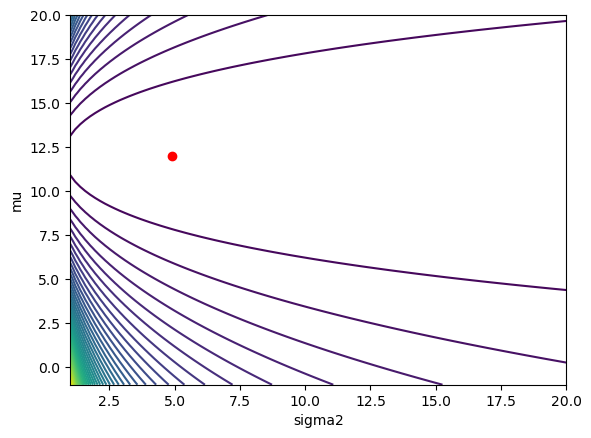

In [292]:
neg_log_L_2params_grid = np.reshape(neg_log_L_2params, (101, 101), order="C")

plt.contour(sigma2_values, mu_values, neg_log_L_2params_grid, levels=50)
plt.xlabel("sigma2")
plt.ylabel("mu")

# overlay MLE
plt.scatter(result.x[1], result.x[0], color="r")

plt.show()

Let's compare our MLE estimates of all our parameters here to the point-estimates.

Firstly, for the binomial distribution, MLE of the p-value returned: 0.7. What happens if we calculate the mean frequency of heads in that dataset?

In [295]:
# original binomial data
x = np.array([1, 1, 1, 0, 1, 0, 1, 1, 0, 1])

probability_heads = x.sum()/len(x)
print(probability_heads)

0.7


In [297]:
# original normal data
x = np.random.normal(loc=12, scale=2.3, size=1000)
print(x.mean())

11.98995529529891


In both cases the MLE estimate is identical (or extremely close) to the point estimate. Let's compare the variances (sigma2).

In [300]:
# sample variance normalised by n-1
print(np.var(x))

4.836608686007137


In [302]:
# sample variance normalised by n only
print(np.var(x)*((len(x)-1)/len(x)))

4.83177207732113


The MLE returns a value closer to *biased* sample variance (normalised by n and not n-1). Theoretically, the MLE does give a biased estimate of the population variance. 

You may have noticed that the estimated values return a parabola (with either a minimum or maximum, depended on whether you've calculated log-likelihood or negative log-likelihood). Therefore the maximum (or minimum) value could be calculated by taking the first derivative of the likelihood equation (i.e. the gradient) and setting that to zero. Differentiation like this is used widely in statistics to find or characterise minima and maxima of functions, particularly when optimising functions such as likelihoods and loss functions (which are used in machine learning). 